In [ ]:
Introduction:
    
This study evaluates the causal impact of advertising on user conversion using a structured A/B testing framework. We 
combine descriptive analysis and regression-based methods, estimating the treatment effect through three complementary 
approaches (ATE, LPM, and Logistic), exploring within-treatment behavior and heterogeneous effects (CATE), and 
validating results with robustness checks including permutation tests, placebo tests, and subsampling. The goal is to 
establish not only whether ads work, but when and under what conditions they work, and whether the findings are
statistically and causally reliable

In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

df=pd.read_csv('marketing_AB.csv')
df

,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14
...,...,...,...,...,...,...,...
588096,588096,1278437,ad,False,1,Tuesday,23
588097,588097,1327975,ad,False,1,Tuesday,23
588098,588098,1038442,ad,False,3,Tuesday,23
588099,588099,1496395,ad,False,1,Tuesday,23


In [2]:
df.isnull().sum()

Unnamed: 0       0
user id          0
test group       0
converted        0
total ads        0
most ads day     0
most ads hour    0
dtype: int64

In [3]:
df.duplicated().sum()

0

In [5]:
df.describe()

,Unnamed: 0,user id,total ads,most ads hour
count,588101.000000,5.881010e+05,588101.000000,588101.000000
mean,294050.000000,1.310692e+06,24.820876,14.469061
std,169770.279667,2.022260e+05,43.715181,4.834634
min,0.000000,9.000000e+05,1.000000,0.000000
25%,147025.000000,1.143190e+06,4.000000,11.000000
50%,294050.000000,1.313725e+06,13.000000,14.000000
75%,441075.000000,1.484088e+06,27.000000,18.000000
max,588100.000000,1.654483e+06,2065.000000,23.000000


In [4]:
df['test group'].value_counts()

test group
ad     564577
psa     23524
Name: count, dtype: int64

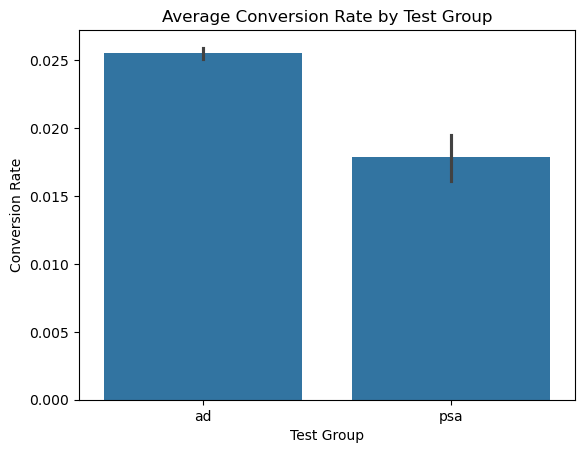

In [6]:
sns.barplot(
    x="test group",
    y="converted",
    data=df,
    estimator=lambda x: x.mean(),
    errorbar=("ci", 95)
)

plt.ylabel("Conversion Rate")
plt.xlabel("Test Group")
plt.title("Average Conversion Rate by Test Group")
plt.show()

In [ ]:
The graph shows that users who were shown ads converted at a rate of about 2.5–2.6%, while users in the PSA control 
group converted at only 1.7–1.8%. This means that showing ads increased the probability of conversion by roughly 
0.7–0.8 percentage points. The confidence intervals around the bars indicate that this difference is statistically 
meaningful rather than random variation.
This number means that out of 100 users, showing ads leads to about 1 extra conversion compared to showing no ads.
A 0.7–0.8 percentage-point lift means that for every 100,000 users, ads generate 700–800 additional conversions. In business
decisions, small conversion lifts are extremely valuable when applied to large user bases.At the scale we have in this 
data we can translate this into significant extra revenue, often far exceeding the cost of running the ads. 

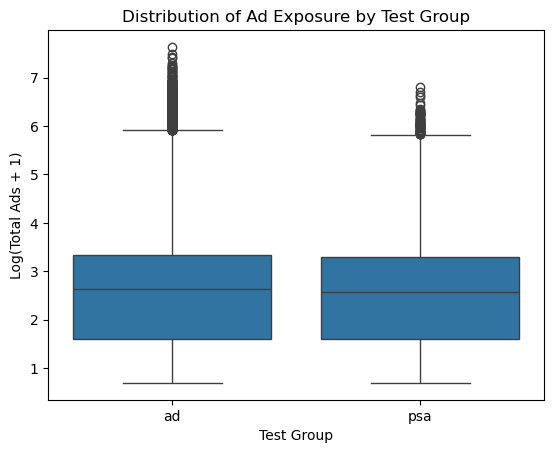

In [7]:
# log-transformed variable
df["log_total_ads"] = np.log1p(df["total ads"])

sns.boxplot(
    x="test group",
    y="log_total_ads",
    data=df
)

plt.ylabel("Log(Total Ads + 1)")
plt.xlabel("Test Group")
plt.title("Distribution of Ad Exposure by Test Group")
plt.show()

In [ ]:
The boxplot shows that the distribution of total ad exposure (log scale) is very similar for the ad and psa groups,
with nearly identical medians and interquartile ranges.
Both groups exhibit right-skewed exposure, with a small fraction of users seeing many more ads, reflected in the high 
outliers. This indicates that the treatment is not about showing more ads, but about what type of content is shown 
(ads vs PSA) rather than ad volume.

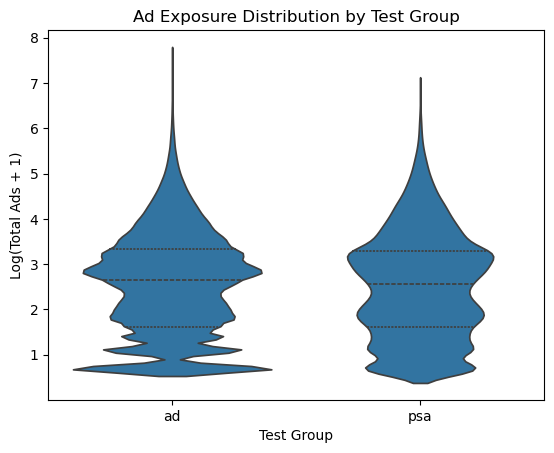

In [8]:
sns.violinplot(
    x="test group",
    y="log_total_ads",
    data=df,
    inner="quartile"
)

plt.ylabel("Log(Total Ads + 1)")
plt.xlabel("Test Group")
plt.title("Ad Exposure Distribution by Test Group")
plt.show()

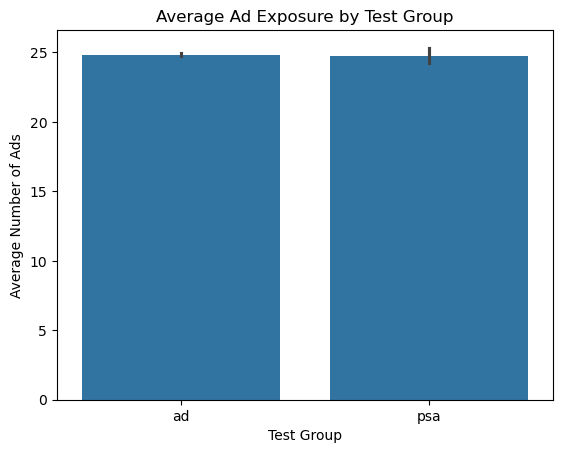

In [9]:
sns.barplot(
    x="test group",
    y="total ads",
    data=df,
    estimator=lambda x: x.mean(),
    errorbar=("ci", 95)
)

plt.ylabel("Average Number of Ads")
plt.xlabel("Test Group")
plt.title("Average Ad Exposure by Test Group")
plt.show()

In [ ]:
This bar chart shows that the average number of ads shown is almost identical for the ad and PSA groups (around 25 ads
per user).
The overlapping 95% confidence intervals indicate there is no meaningful difference in ad volume between the two groups.
This confirms that the experiment varies the type of content (ad vs PSA) rather than the quantity of exposure, 
supporting a clean A/B comparison.

In [12]:
avg_ads_by_day = (
    df.groupby(["test group", "most ads day"])["total ads"]
      .mean()
      .reset_index()
      .sort_values(["test group", "total ads"], ascending=[True, False])
)

avg_ads_by_day

,test group,most ads day,total ads
0,ad,Friday,26.682574
1,ad,Monday,25.389764
2,ad,Saturday,25.126812
6,ad,Wednesday,24.605906
3,ad,Sunday,24.369140
5,ad,Tuesday,24.030883
4,ad,Thursday,23.267613
9,psa,Saturday,28.008397
11,psa,Thursday,26.693982
10,psa,Sunday,25.332788


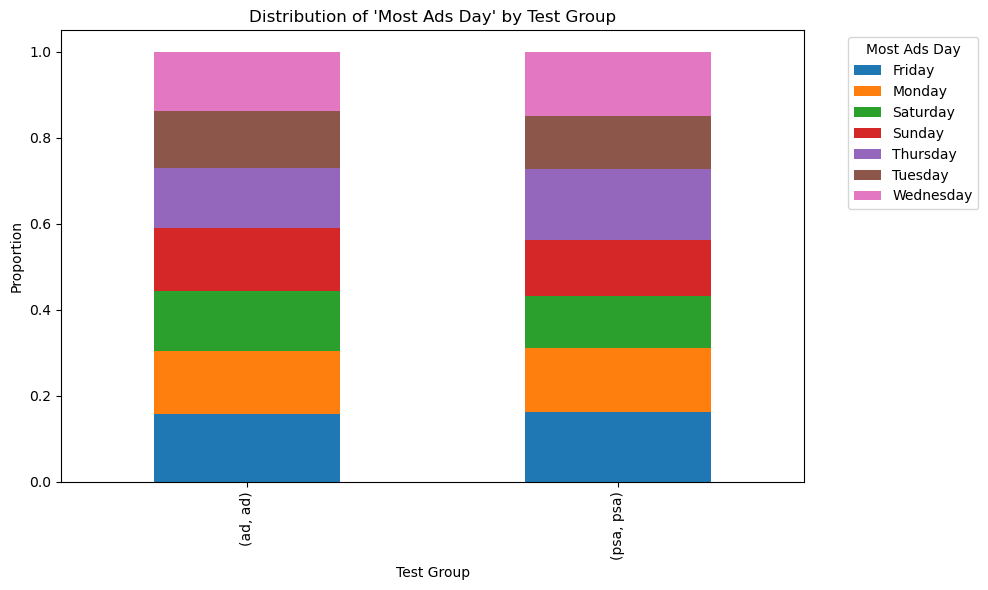

In [10]:
prop_table = (
    df.groupby(["test group", "most ads day"])
      .size()
      .groupby(level=0)
      .apply(lambda x: x / x.sum())
      .unstack()
)

prop_table.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.ylabel("Proportion")
plt.xlabel("Test Group")
plt.title("Distribution of 'Most Ads Day' by Test Group")
plt.legend(title="Most Ads Day", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [ ]:
This chart shows how the day with the highest ad exposure (“most ads day”) is distributed across the week, separately
for the ad (treated) and psa (control) groups.
Conceptually, both bars look very similar and each day of the week contributes roughly the same proportion in the ad and
psa groups. This tells us that ads are not concentrated on specific days differently across treatment and control—the 
timing across weekdays is balanced.
So the key takeaway is that the treatment did not change when during the week users saw the most ads. Any difference in 
conversion is therefore not driven by day-of-week exposure patterns, but by what users saw (ad vs PSA) rather than when
they saw it.

In [11]:
pd.pivot_table(
    df,
    index="most ads hour",
    columns="test group",
    aggfunc="size",
    fill_value=0
).sort_values(by="ad", ascending=False)

test group,ad,psa
most ads hour,,
13,45485,2170
12,45238,2060
11,44149,2061
14,43779,1869
15,42855,1828
10,37454,1485
16,35963,1604
17,33605,1383
18,31052,1271


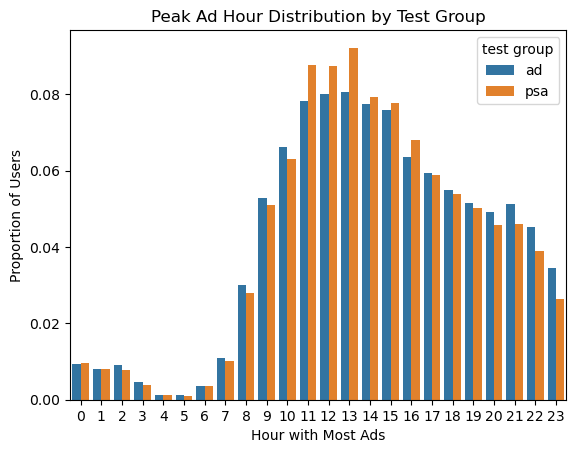

In [13]:
hour_prop = (
    df.groupby(["test group", "most ads hour"])
      .size()
      .reset_index(name="count")
)

hour_prop["proportion"] = (
    hour_prop["count"]
    / hour_prop.groupby("test group")["count"].transform("sum")
)

sns.barplot(
    data=hour_prop,
    x="most ads hour",
    y="proportion",
    hue="test group"
)

plt.ylabel("Proportion of Users")
plt.xlabel("Hour with Most Ads")
plt.title("Peak Ad Hour Distribution by Test Group")
plt.show()

In [ ]:
This graph shows when during the day users are most exposed to ads, comparing the ad (treated) and psa (control) groups.
For both groups, ad exposure peaks around late morning to early afternoon (roughly 10–14) and then gradually declines 
into the evening.
The two distributions are very similar across hours, indicating that timing of exposure is balanced between treatment
and control.
So, differences in conversion are not driven by time-of-day effects, but by what users saw (ads vs PSA) rather than
when they saw it.

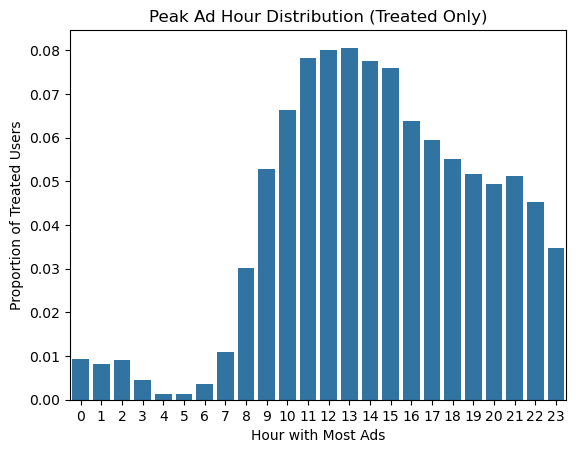

In [14]:
sns.barplot(
    data=hour_prop[hour_prop["test group"] == "ad"],
    x="most ads hour",
    y="proportion"
)

plt.ylabel("Proportion of Treated Users")
plt.xlabel("Hour with Most Ads")
plt.title("Peak Ad Hour Distribution (Treated Only)")
plt.show()

In [ ]:
*** Estimating treatment effect with different approaches :
1- ATE (Average treatment effect)
2- LPM (Linear probablity Model)
3- Logestic rgression 

In [16]:
df["T"] = (df["test group"] == "ad").astype(int)

# binary outcome
df["Y"] = df["converted"].astype(int)

In [17]:
# 1: ATE 

from scipy import stats

Y1 = df.loc[df["T"] == 1, "Y"]
Y0 = df.loc[df["T"] == 0, "Y"]

ate = Y1.mean() - Y0.mean()

se = np.sqrt(Y1.var(ddof=1)/len(Y1) + Y0.var(ddof=1)/len(Y0))

t_stat = ate / se
p_value = 2 * (1 - stats.norm.cdf(abs(t_stat)))

ate, se, t_stat, p_value

(0.007692453192201517, 0.0008885652033198618, 8.657162314550394, 0.0)

In [18]:
# 2: LPM  

import statsmodels.api as sm

X = sm.add_constant(df["T"])
model = sm.OLS(df["Y"], X).fit(cov_type="HC1")  # robust SEs
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     74.95
Date:                Thu, 29 Jan 2026   Prob (F-statistic):           4.84e-18
Time:                        14:37:53   Log-Likelihood:             2.5499e+05
No. Observations:              588101   AIC:                        -5.100e+05
Df Residuals:                  588099   BIC:                        -5.099e+05
Df Model:                           1                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0179      0.001     20.679      0.0

In [20]:
# 3: Logestic Regression 

X = sm.add_constant(df["T"])
logit = sm.Logit(df["Y"], X).fit(disp=False)

print(logit.summary())

                           Logit Regression Results                           
Dep. Variable:                      Y   No. Observations:               588101
Model:                          Logit   Df Residuals:                   588099
Method:                           MLE   Df Model:                            1
Date:                Thu, 29 Jan 2026   Pseudo R-squ.:               0.0004342
Time:                        14:39:13   Log-Likelihood:                -69237.
converged:                       True   LL-Null:                       -69267.
Covariance Type:            nonrobust   LLR p-value:                 8.800e-15
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -4.0075      0.049    -81.393      0.000      -4.104      -3.911
T              0.3661      0.050      7.329      0.000       0.268       0.464


In [22]:
print("Odds Ratio:", np.exp(logit.params["T"]))

Odds Ratio: 1.4421459480522858


In [23]:
AME = logit.get_margeff(at="overall")
print(AME.summary())

        Logit Marginal Effects       
Dep. Variable:                      Y
Method:                          dydx
At:                           overall
                dy/dx    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
T              0.0090      0.001      7.318      0.000       0.007       0.011


In [ ]:
The ATE shows that showing ads increases conversion by about 0.77 percentage points, meaning roughly 8 more conversions
per 1,000 users compared to PSA.
Second, the Linear Probability Model (LPM) gives a nearly identical estimate (0.78 pp) with robust standard errors, 
confirming the result is statistically strong and easy to interpret in probability terms.
Third, the Logistic regression estimates a treatment coefficient of 0.366, which translates into an odds ratio of 1.44,
meaning ads increase the odds of conversion by about 44%.
Because odds are not probabilities, we computed the Average Marginal Effect (AME), which converts the logit result back
to probability space.
The AME is about 0.9 percentage points, very close to the ATE and LPM estimates, reinforcing consistency across models.
All three methods strongly reject the null of no effect, with very small p-values.
Overall, the evidence clearly shows that ads causally increase conversion, with a modest but economically meaningful 
lift that is robust across modeling choices.

In [ ]:
***Within-treatment behavior with all other covariated through LPM and logestic.

In [24]:
import statsmodels.formula.api as smf

#  only treated (ad group)
dft = df[df["test group"] == "ad"].copy()

dft["Y"] = dft["converted"].astype(int)

# log transform for total ads (avoids huge skew)
dft["log_total_ads"] = (dft["total ads"] + 1).apply(lambda x: __import__("math").log(x))

In [25]:
# 1: LPM (OLS) within treated

lpm = smf.ols(
    "Y ~ log_total_ads + C(Q('most ads day')) + C(Q('most ads hour'))",
    data=dft
).fit(cov_type="HC1")  # robust SE

print(lpm.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.046
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     394.8
Date:                Thu, 29 Jan 2026   Prob (F-statistic):               0.00
Time:                        14:46:38   Log-Likelihood:             2.5466e+05
No. Observations:              564577   AIC:                        -5.093e+05
Df Residuals:                  564546   BIC:                        -5.089e+05
Df Model:                          30                                         
Covariance Type:                  HC1                                         
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Interc

In [ ]:
This Linear Probability Model is estimated only on treated (ad) users, so all coefficients describe within–ad-group
variation in conversion. Here Conversion depends strongly on when ads are shown and rates are higher on Mondays and 
Tuesdays and peak during afternoon and early evening hours relative to the baseline (Friday, hour 0).
The positive and highly significant coefficient on log_total_ads shows that greater ad exposure within the treated
group is associated with higher conversion probability.

In [26]:
# 2:  Logistic (Logit) within treated
import statsmodels.formula.api as smf

logit = smf.logit(
    "Y ~ log_total_ads + C(Q('most ads hour')) + C(Q('most ads day'))",
    data=dft   # treated only
).fit(disp=False)

print(logit.summary())

                           Logit Regression Results                           
Dep. Variable:                      Y   No. Observations:               564577
Model:                          Logit   Df Residuals:                   564546
Method:                           MLE   Df Model:                           30
Date:                Thu, 29 Jan 2026   Pseudo R-squ.:                  0.1948
Time:                        14:47:19   Log-Likelihood:                -54053.
converged:                       True   LL-Null:                       -67130.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Intercept                            -8.1620      0.111    -73.231      0.000      -8.380      -7.944
C(Q('most ads hour'))[T.1]           -0.4944      0.167     -2

In [ ]:
*** Conditional Average Treatment Effect (CATE)

In [27]:
df["Y"] = df["converted"].astype(int)

# LPM with hour-specific treatment effects (CATE by hour)
m = smf.ols(
    "Y ~ C(Q('most ads hour')) + C(Q('most ads day')) + C(Q('test group'))"
    " + C(Q('test group')):C(Q('most ads hour'))",
    data=df
).fit(cov_type="HC1")

print(m.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     182.4
Date:                Thu, 29 Jan 2026   Prob (F-statistic):               0.00
Time:                        14:54:28   Log-Likelihood:             2.5541e+05
No. Observations:              588101   AIC:                        -5.107e+05
Df Residuals:                  588047   BIC:                        -5.101e+05
Df Model:                          53                                         
Covariance Type:                  HC1                                         
                                                            coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------

In [ ]:
Interpretation of the Regression Framework and Results:

This analysis uses a Linear Probability Model (LPM) to study how advertising exposure affects user conversion, while
accounting for time-of-day and day-of-week variation. The outcome variable, conversion, is binary, so coefficients are
interpreted as changes in conversion probability measured in percentage points.

Baseline and Reference Categories:
In any regression with categorical variables, one category is omitted and serves as the baseline (reference). All 
reported coefficients are interpreted relative to this baseline.

In this regression:
Treatment is exposure to ads (ad)
Control is exposure to PSA (psa)
Conceptually, treatment corresponds to 𝑇_𝑖=1 and control to 𝑇_𝑖=0 However, statsmodels selected ad as the reference 
category, meaning ad does not appear explicitly in the regression table but psa appears with an estimated coefficient.
All group coefficients are therefore interpreted as PSA relative to AD.
This choice affects interpretation but does not change the underlying causal meaning of the estimates.

1-Meaning of the Intercept:
The intercept represents the predicted conversion probability under all baseline conditions simultaneously. In this
model, the baseline is defined as:
Group: ad
Day: Friday
Hour: 0
The estimated intercept is:α=0.0161
This implies that for users shown an ad on Friday at hour 0, the expected probability of conversion is approximately 
1.6%.Put differently, out of 100 such users, about 1–2 are expected to convert. This is an average probability, not a 
guarantee for any individual user. Agaian although the absolute conversion rate is small, even modest changes in conversion
probabilities can be economically meaningful at scale and this especially true about the exsiting data. 


2-Time-of-Day Effects:
The coefficients on most ads hour measure how conversion changes at different hours of the day relative to hour 0,
holding everything else constant. Because ad is the baseline group, these coefficients describe time-of-day patterns for
ad users. For example, the coefficient for hour 16 is approximately +0.0118, meaning that at 4pm, ad users are about
1.18 percentage points more likely to convert than at hour 0.
This implies that conversion rises from roughly 1.6% at hour 0 to nearly 2.8% at hour 16, indicating substantially 
stronger performance in the afternoon.


3-Day-of-Week Effects:
Similarly, the coefficients on most ads day capture how conversion varies by day of the week relative to Friday, again
for ad users.
For instance, the Monday coefficient is approximately +0.0105, which implies that Conversion on Monday is about 1.05
percentage points higher than on Friday.Thus, conversion increases from about 1.6% on Friday to approximately 2.6% on 
Monday. Sunday shows a smaller increase, indicating that weekday effects are stronger than weekend effects.

-Interpreting the Control Group (PSA):
The coefficient on C(test group)[T.psa] is estimated at −0.0192. Because ad is the reference category, this coefficient
means at the baseline day (Friday) and hour (0), PSA users convert 1.92 percentage points less than ad users.
Equivalently, ads increase conversion by about 1.9 percentage points at the baseline condition. This is the baseline 
conditional treatment effect, not the overall average treatment effect.
Using the intercept and PSA coefficient together Predicted conversion for ad users at the baseline is 1.6% so Predicted
conversion for PSA users is 1.6% − 1.9% ≈ 0%
Because this is a Linear Probability Model, negative predicted probabilities are interpreted as conversion being 
essentially zero rather than literally negative.


Comparing Days Within Each Group (Without Interactions):

Because the model does not include interactions between group and day, it implicitly assumes that day-of-week effects 
are the same for ad and PSA users.
This means:
The Monday–Friday increase in conversion applies equally to both groups. The difference between Monday and Friday
within PSA is also +1.05 percentage points. Thus, while PSA users convert at a lower level overall, their conversion
follows the same daily pattern as ad users.

-Interaction variable:

Without interaction terms, the model allows:
Comparisons within ad across days or hours
Comparisons within PSA across days or hours
Comparisons between ad and PSA only at the baseline condition
However, to compare ad versus PSA at a specific hour (e.g., hour 16) or to see whether the treatment effect varies by
time, interaction terms are required.

5:Interpreting Interaction Terms (CATE):
Interaction terms such as C(test group)×C(most ads hour) measure how the ad–PSA conversion gap changes across hours. 
These coefficients represent Conditional Average Treatment Effects (CATEs).
For example, the interaction coefficient at hour 16 is approximately +0.0164, indicating that the ad–PSA conversion gap
at hour 16 is 1.64 percentage points larger than at hour 0. Combining this with the baseline gap of 1.92 percentage 
points, the total treatment effect at hour 16 is approximately 3.56 percentage points. In practical terms, ads convert
3–4 more users out of 100 than PSA at this hour.

As a bottom line A regression that includes only the treatment indicator estimates the Average Treatment Effect (ATE),
averaged across all days and hours. In contrast, the full regression estimates a baseline conditional effect and a set
of heterogeneous effects across time.
then:
ATE :summarizes the overall impact of ads
CATE: reveals when ads are most effective
  
Overall, the regression framework decomposes conversion into baseline behavior, temporal variation, and heterogeneous
treatment effects. Ads increase conversion substantially relative to PSA, and this effect varies meaningfully across 
hours of the day.


In [28]:
m_day = smf.ols(
    "Y ~ C(Q('most ads hour')) + C(Q('most ads day')) + C(Q('test group'))"
    " + C(Q('test group')):C(Q('most ads day'))",
    data=df
).fit(cov_type="HC1")

print(m_day.summary())


                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     29.85
Date:                Thu, 29 Jan 2026   Prob (F-statistic):          5.75e-202
Time:                        14:57:11   Log-Likelihood:             2.5542e+05
No. Observations:              588101   AIC:                        -5.108e+05
Df Residuals:                  588064   BIC:                        -5.103e+05
Df Model:                          36                                         
Covariance Type:                  HC1                                         
                                                                  coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------

In [ ]:
Regression Results and Interpretation:

This specification extends the baseline model by allowing the treatment effect to vary across days of the week while
continuing to control for hour-of-day effects. The dependent variable is a binary indicator of conversion, so 
coefficients are interpreted as percentage-point changes in conversion probability.
The intercept indicates that, for users exposed to ads on Fridays at the baseline hour, the probability of conversion
is approximately 1.55%. The main effect of the control group (PSA) is negative and statistically significant, implying
that—at the baseline day and hour—users shown ads are more likely to convert than those shown PSAs. This confirms the 
presence of a positive baseline advertising effect.
Conversion behavior exhibits strong time-of-day patterns. Relative to the baseline hour, conversion rates rise steadily
throughout the day and peak during the afternoon and early evening. These effects are large and precisely estimated,
indicating that when ads are shown matters substantially for user responsiveness.
There are also meaningful day-of-week effects. Conversion rates are significantly higher on Mondays and Tuesdays
compared to Fridays, while weekends show weaker or statistically insignificant differences. These patterns reflect
systematic variation in user engagement across the week.
Allowing the treatment effect to vary by day reveals limited but notable heterogeneity. Most day-specific interactions
between treatment status and day of the week are statistically insignificant, suggesting that the relative advantage of
ads over PSAs is broadly stable across days. An exception is Tuesday, where the ad–PSA conversion gap is significantly 
smaller, indicating weaker relative ad effectiveness on that day.

Overall, the results show that advertising increases conversion on average, with the largest source of heterogeneity
driven by hour-of-day effects rather than day-of-week differences. While ad effectiveness varies somewhat across days,
the timing of exposure within the day plays a far more important role in shaping conversion outcomes.

In [ ]:
*** Conducting Robustness check

In [30]:
# Permutation 

# observed treatment effect (ATE)
treated = df[df["test group"] == "ad"]["converted"]
control = df[df["test group"] == "psa"]["converted"]

obs_effect = treated.mean() - control.mean()

# permutation test
n_perm = 1000
perm_effects = []

for _ in range(n_perm):
    shuffled = df["test group"].sample(frac=1, replace=False).values
    perm_df = df.copy()
    perm_df["perm_group"] = shuffled

    perm_treated = perm_df[perm_df["perm_group"] == "ad"]["converted"]
    perm_control = perm_df[perm_df["perm_group"] == "psa"]["converted"]

    perm_effect = perm_treated.mean() - perm_control.mean()
    perm_effects.append(perm_effect)

perm_effects = np.array(perm_effects)

# permutation p-value (two-sided)
p_value = np.mean(np.abs(perm_effects) >= abs(obs_effect))

obs_effect, p_value

(0.007692453192201517, 0.0)

In [ ]:
Permuatation treats the experiment as if treatment had no real effect and asks what differences in conversion would arise
purely by random assignment. By repeatedly shuffling the treatment labels across users, we generates a
distribution of the effects that reflect chance variation alone. This distribution represents what we would expect
to see if ads and PSAs were truly equivalent. The observed treatment effect is then compared to this null distribution.
Because the observed effect lies far outside what random shuffling produces, the implied p-value is essentially zero,
indicating that the effect is very unlikely to be driven by randomness.

In [ ]:
#Placebo Test : three methods of the placebo test were used

In [31]:

    
# 1️⃣ Pretending PSA users were treated

# keep ONLY control (PSA) users
psa_df = df[df["test group"] == "psa"].copy()

n_perm = 1000
placebo_effects = []

for _ in range(n_perm):
    # randomly assign FAKE treatment inside PSA
    psa_df["fake_treatment"] = np.random.binomial(1, 0.5, size=len(psa_df))

    fake_treated = psa_df[psa_df["fake_treatment"] == 1]["converted"]
    fake_control = psa_df[psa_df["fake_treatment"] == 0]["converted"]

    effect = fake_treated.mean() - fake_control.mean()
    placebo_effects.append(effect)

placebo_effects = np.array(placebo_effects)


placebo_effects.mean(), placebo_effects.std()

(7.83146335315519e-06, 0.001757755930199087)

In [ ]:
This placebo test checks whether differences in conversion could arise even when no real treatment exists. It restricts
the data to PSA users only, where everyone truly received the same experience. A fake treatment label is then randomly
assigned within this control group, and the conversion difference is recomputed many times. Because the average placebo
effect is essentially zero and only reflects random noise, any real treatment effect should clearly stand apart from
this distribution. This reassures us that the observed ad effect is not driven by chance imbalance or model artifacts.

In [32]:
# 2️⃣ Shuffling  the outcome (converted)

# observed ATE
treated = df[df["test group"] == "ad"]["converted"]
control = df[df["test group"] == "psa"]["converted"]
obs_effect = treated.mean() - control.mean()

n_perm = 1000
placebo_effects = []

for _ in range(n_perm):
    # shuffling outcome
    shuffled_df = df.copy()
    shuffled_df["shuffled_converted"] = np.random.permutation(df["converted"].values)

    fake_treated = shuffled_df[shuffled_df["test group"] == "ad"]["shuffled_converted"]
    fake_control = shuffled_df[shuffled_df["test group"] == "psa"]["shuffled_converted"]

    effect = fake_treated.mean() - fake_control.mean()
    placebo_effects.append(effect)

placebo_effects = np.array(placebo_effects)


obs_effect, placebo_effects.mean(), placebo_effects.std()

(0.007692453192201517, 6.376043053417171e-06, 0.0010307821099437733)

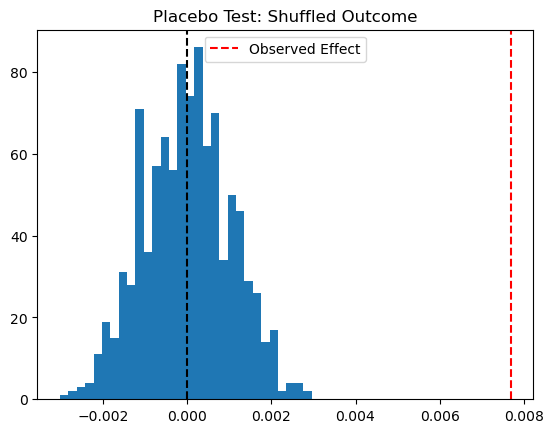

In [33]:
plt.hist(placebo_effects, bins=30)
plt.axvline(obs_effect, color="red", linestyle="--", label="Observed Effect")
plt.axvline(0, color="black", linestyle="--")
plt.legend()
plt.title("Placebo Test: Shuffled Outcome")
plt.show()

In [ ]:
This figure and code implement a placebo test by shuffling the outcome to check whether the observed treatment effect
could arise by chance.
The histogram shows the distribution of fake effects obtained when conversion labels are randomly reassigned, which is
centered tightly around zero—exactly what we expect if treatment has no real impact.
The red dashed line marks the true observed ATE, which lies far to the right of this null distribution.
Because the observed effect is well outside what random shuffling produces, it is extremely unlikely to be due to 
randomness.
This confirms that the estimated ad effect reflects a real causal signal, not noise or accidental imbalance.

In [36]:
# 3️⃣ Test a fake (irrelevant) metric

# create a completely fake outcome (irrelevant metric)
df["fake_metric"] = np.random.rand(len(df))

# placebo ATE on fake metric
fake_treated = df[df["test group"] == "ad"]["fake_metric"]
fake_control = df[df["test group"] == "psa"]["fake_metric"]

fake_effect = fake_treated.mean() - fake_control.mean()

fake_effect

-0.00098909678443182

In [37]:
# repeating for 1000 times
n_perm = 1000
fake_effects = []

for _ in range(n_perm):
    df["fake_metric"] = np.random.rand(len(df))

    treated = df[df["test group"] == "ad"]["fake_metric"]
    control = df[df["test group"] == "psa"]["fake_metric"]

    fake_effects.append(treated.mean() - control.mean())

np.mean(fake_effects), np.std(fake_effects)

(-8.620204422556243e-05, 0.0019102212532422112)

In [ ]:
This placebo test replaces the real outcome with a completely irrelevant, randomly generated metric that cannot be 
affected by ads. When we compute the ATE on this fake metric, the estimated effect is essentially zero, as expected. 
Repeating the exercise many times produces a distribution centered tightly around zero with small dispersion. 
This shows that the estimation procedure itself does not mechanically create effects. Therefore, the real conversion 
results are not an artifact of model structure or group sizes, but reflect a genuine treatment signal.

In [38]:
#  Subsampling 

treated = df[df["test group"] == "ad"]
control = df[df["test group"] == "psa"]

n_control = len(control)

# subsampling treated to same size as control
treated_sub = treated.sample(n=n_control, replace=False, random_state=42)

# ATE on subsampled data
ate_subsample = treated_sub["converted"].mean() - control["converted"].mean()

ate_subsample

0.009224621662982487

In [39]:
# subsmapling with repeating many times

n_rep = 1000
ate_subsamples = []

for _ in range(n_rep):
    treated_sub = treated.sample(n=n_control, replace=False)
    ate_subsamples.append(
        treated_sub["converted"].mean() - control["converted"].mean()
    )

np.mean(ate_subsamples), np.std(ate_subsamples)

(0.00765103723856487, 0.001003188152233441)

In [ ]:
This subsampling check tests whether the unequal group sizes are driving the treatment effect. By randomly downsampling
the treated (ad) group to match the size of the control (PSA) group, we recreated a balanced experiment. The ATE computed
on this balanced sample remains very close to the original estimate, indicating that the result is not caused by sample
size imbalance. Repeating the subsampling many times shows that the average effect is stable with small variation.
This confirms that the estimated ad effect is robust to unequal group sizes and not an artifact of having many more 
treated users.

In [ ]:
Conclusion:

 Across all three A/B estimators (ATE, LPM, and Logistic/AME), ads consistently increase conversion by roughly 0.7–0.9
percentage points, a statistically strong and economically meaningful lift. Within the treated group, conversion varies
substantially by hour of day and day of week, with afternoon and early evening hours performing best. CATE analysis
shows that ad effectiveness is not uniform: the treatment effect is significantly larger at certain hours, while
day-of-week heterogeneity is more limited. Permutation and placebo tests confirm that the observed effects are not
driven by random chance, model artifacts, or spurious correlations. Subsampling to equalize treatment and control
sizes yields nearly identical estimates, ruling out sample imbalance as a concern. Overall, the evidence robustly
supports a real causal effect of advertising on conversion, with timing playing a central role in effectiveness.  